In [1]:
import sys
from pathlib import Path

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

# Now import from src
from src.data.fetch_nasa_omni_historical import load_and_clean_nasa_omni_historical

For our baseline, we load the 2023 historical NASA OMNI data. 
Note, this data has been "synced up" in terms of timing.
The input features are observed by various NASA satellites as far out as the L1 Lagrange point, but NASA has lined up the historical data so the input features match the output feature at the time of the solar wind hitting the magnetosphere.

In [2]:
data = load_and_clean_nasa_omni_historical(2023, "../data/raw/")
print(data.head())

2026-03-04 14:47:24,268 - INFO - Found existing raw data file for year 2023 at ../data/raw/omni2_2023_raw.csv. Loading...


                     Year  DOY  Hour  IMF_Mag  Bx_GSE  By_GSE  Bz_GSE  \
Timestamp                                                               
2023-01-01 00:00:00  2023  1.0     0     -1.9     4.6    -0.7     4.6   
2023-01-01 01:00:00  2023  1.0     1     -3.9    -0.6     0.6    -0.7   
2023-01-01 02:00:00  2023  1.0     2     -3.9    -1.2     1.5    -1.5   
2023-01-01 03:00:00  2023  1.0     3     -3.4     1.5     0.4     1.4   
2023-01-01 04:00:00  2023  1.0     4     -2.4     2.7     0.7     2.6   

                     Proton_Density  Plasma_Speed  Kp_index  Kp_real  
Timestamp                                                             
2023-01-01 00:00:00             2.4         603.0        23      2.3  
2023-01-01 01:00:00             2.6         582.0        23      2.3  
2023-01-01 02:00:00             2.6         581.0        23      2.3  
2023-01-01 03:00:00             2.4         576.0        30      3.0  
2023-01-01 04:00:00             2.5         585.0        30   

A geomagnetic storm is typically defined as $K_p \geq 5$. However, geomagnetic storms are relatively rare events. Below we have a histogram of the $K_p$ values for 2023.
Thus, our model will have to deal with the data imbalance or the scarcity of solar storms.

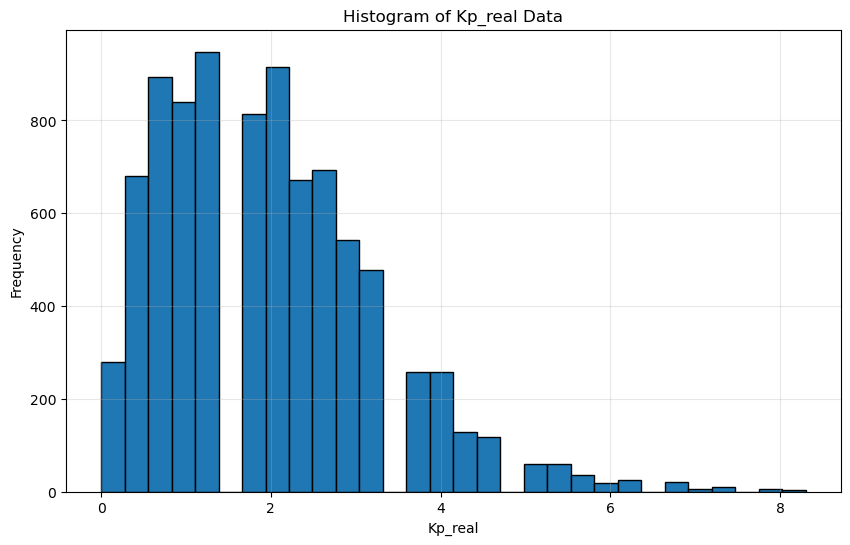

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(data['Kp_real'].dropna(), bins=30, edgecolor='black')
plt.xlabel('Kp_real')
plt.ylabel('Frequency')
plt.title('Histogram of Kp_real Data')
plt.grid(True, alpha=0.3)
plt.show()

In 2023, only 2.8% of hours would be considered storms.

In [4]:
# Compute percentage of Kp_real values above 5 versus below 5
kp_above_5 = (data['Kp_real'] >= 5).sum()
kp_below_5 = (data['Kp_real'] < 5).sum()
total_valid = data['Kp_real'].notna().sum()

percent_above_5 = (kp_above_5 / total_valid) * 100
percent_below_5 = (kp_below_5 / total_valid) * 100

print(f"Kp_real >= 5: {kp_above_5} ({percent_above_5:.2f}%)")
print(f"Kp_real < 5: {kp_below_5} ({percent_below_5:.2f}%)")

Kp_real >= 5: 243 (2.77%)
Kp_real < 5: 8517 (97.23%)


Let us add `IsStorm` as a column in our data for classification.

In [5]:
data['Is_Storm'] = (data['Kp_real'] >= 5.0).astype(int)
df_final = data.dropna()

Now, let us do a sequential split and evaluate how various baseline models perform. 
Note, below, we will do a time aware cross-validation, but for now, we just want to get a sense of the data.

In [6]:
# Sequential Split (Keep time order)
X = df_final[['IMF_Mag', 'Bx_GSE', 'By_GSE', 'Bz_GSE', 'Proton_Density', 'Plasma_Speed']]
y = df_final['Is_Storm']
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [7]:
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Define models
classification_models = {
    "DummyClassifier": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
}

regression_models = {
    "DummyRegressor": DummyRegressor(strategy="mean"),
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
}

results = []

# Train and evaluate classifiers
for name, model in classification_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # ROC-AUC where possible
    roc_auc = np.nan
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_score)

    results.append({
        "Model": name,
        "Type": "Classifier",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc,
        "MSE": np.nan,
        "MAE": np.nan,
        "R2": np.nan
    })

# Train and evaluate regressors
for name, model in regression_models.items():
    model.fit(X_train, y_train)
    y_pred_cont = model.predict(X_test)

    # Regression metrics
    mse = mean_squared_error(y_test, y_pred_cont)
    mae = mean_absolute_error(y_test, y_pred_cont)
    r2 = r2_score(y_test, y_pred_cont)

    # Optional thresholding for classification-style comparison
    y_pred_bin = (y_pred_cont >= 0.5).astype(int)

    results.append({
        "Model": name,
        "Type": "Regressor",
        "Accuracy": accuracy_score(y_test, y_pred_bin),
        "Precision": precision_score(y_test, y_pred_bin, zero_division=0),
        "Recall": recall_score(y_test, y_pred_bin, zero_division=0),
        "F1": f1_score(y_test, y_pred_bin, zero_division=0),
        "ROC_AUC": np.nan,
        "MSE": mse,
        "MAE": mae,
        "R2": r2
    })

results_df = pd.DataFrame(results)
results_df

,Model,Type,Accuracy,Precision,Recall,F1,ROC_AUC,MSE,MAE,R2
0,DummyClassifier,Classifier,0.965753,0.000000,0.000000,0.000000,0.500000,NaN,NaN,NaN
1,LogisticRegression,Classifier,0.968607,0.586207,0.283333,0.382022,0.923128,NaN,NaN,NaN
2,RandomForestClassifier,Classifier,0.968607,0.564103,0.366667,0.444444,0.919213,NaN,NaN,NaN
3,DummyRegressor,Regressor,0.965753,0.000000,0.000000,0.000000,NaN,0.033140,0.058571,-0.002000
4,LinearRegression,Regressor,0.965753,0.500000,0.083333,0.142857,NaN,0.027163,0.078556,0.178724
5,RandomForestRegressor,Regressor,0.964612,0.480769,0.416667,0.446429,NaN,0.026596,0.048582,0.195861


The baseline models have high accuracy, but terrible recall, which is both expected and undesirable; it is better to have a warning about a storm that does not materialize than to experience a storm without warning. The confusion matrices below illustrate that the models typically fail to predict an impending storm.

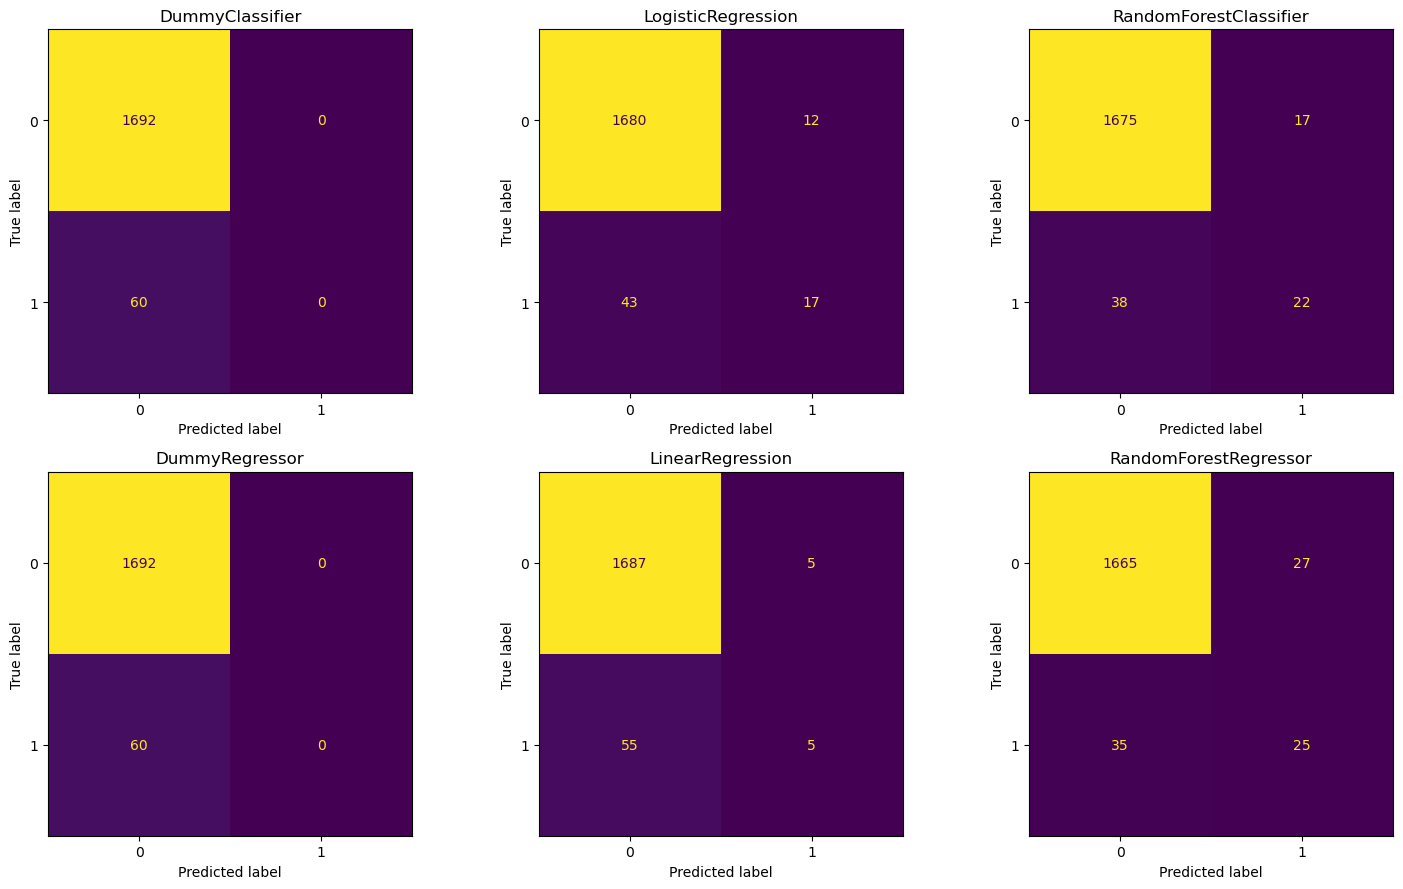

,Model,Type,TN,FP,FN,TP
0,DummyClassifier,Classifier,1692,0,60,0
1,LogisticRegression,Classifier,1680,12,43,17
2,RandomForestClassifier,Classifier,1675,17,38,22
3,DummyRegressor,Regressor,1692,0,60,0
4,LinearRegression,Regressor,1687,5,55,5
5,RandomForestRegressor,Regressor,1665,27,35,25


In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Build confusion matrices for the same 6 baseline models
cm_rows = []
all_models = [
    ("DummyClassifier", classification_models["DummyClassifier"], "Classifier"),
    ("LogisticRegression", classification_models["LogisticRegression"], "Classifier"),
    ("RandomForestClassifier", classification_models["RandomForestClassifier"], "Classifier"),
    ("DummyRegressor", regression_models["DummyRegressor"], "Regressor"),
    ("LinearRegression", regression_models["LinearRegression"], "Regressor"),
    ("RandomForestRegressor", regression_models["RandomForestRegressor"], "Regressor"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for i, (model_name, model_obj, model_type) in enumerate(all_models):
    model_obj.fit(X_train, y_train)

    if model_type == "Classifier":
        y_hat = model_obj.predict(X_test)
    else:
        y_hat_cont = model_obj.predict(X_test)
        y_hat = (y_hat_cont >= 0.5).astype(int)

    cm = confusion_matrix(y_test, y_hat, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    cm_rows.append({
        "Model": model_name,
        "Type": model_type,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]).plot(
        ax=axes[i], colorbar=False, values_format="d"
    )
    axes[i].set_title(model_name)

plt.tight_layout()
plt.show()

confusion_df = pd.DataFrame(cm_rows)
confusion_df

To be more rigorous, let us now do a time aware cross validation on the baseline models.

In [9]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
import numpy as np
import pandas as pd

# Time-aware CV: train on past, validate on future
tscv = TimeSeriesSplit(n_splits=5)

# Use the same six baseline models
all_models = [
    ("DummyClassifier", classification_models["DummyClassifier"], "Classifier"),
    ("LogisticRegression", classification_models["LogisticRegression"], "Classifier"),
    ("RandomForestClassifier", classification_models["RandomForestClassifier"], "Classifier"),
    ("DummyRegressor", regression_models["DummyRegressor"], "Regressor"),
    ("LinearRegression", regression_models["LinearRegression"], "Regressor"),
    ("RandomForestRegressor", regression_models["RandomForestRegressor"], "Regressor"),
]

cv_rows = []

for model_name, base_model, model_type in all_models:
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X), start=1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        base_model.fit(X_tr, y_tr)

        if model_type == "Classifier":
            y_pred = base_model.predict(X_val)
            if hasattr(base_model, "predict_proba"):
                y_score = base_model.predict_proba(X_val)[:, 1]
            elif hasattr(base_model, "decision_function"):
                y_score = base_model.decision_function(X_val)
            else:
                y_score = y_pred
        else:
            y_score = base_model.predict(X_val)
            y_pred = (y_score >= 0.5).astype(int)

        # Some folds can have one class only; guard AUC metrics
        try:
            roc = roc_auc_score(y_val, y_score)
        except ValueError:
            roc = np.nan

        try:
            pr_auc = average_precision_score(y_val, y_score)
        except ValueError:
            pr_auc = np.nan

        cv_rows.append({
            "Model": model_name,
            "Type": model_type,
            "Fold": fold,
            "Train_Start": X_tr.index.min(),
            "Train_End": X_tr.index.max(),
            "Val_Start": X_val.index.min(),
            "Val_End": X_val.index.max(),
            "Accuracy": accuracy_score(y_val, y_pred),
            "Precision": precision_score(y_val, y_pred, zero_division=0),
            "Recall": recall_score(y_val, y_pred, zero_division=0),
            "F1": f1_score(y_val, y_pred, zero_division=0),
            "ROC_AUC": roc,
            "PR_AUC": pr_auc,
        })

cv_results = pd.DataFrame(cv_rows)
display(cv_results)

summary = (
    cv_results
    .groupby(["Type", "Model"])[["Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC"]]
    .agg(["mean", "std"])
)

display(summary)

,Model,Type,Fold,Train_Start,Train_End,Val_Start,Val_End,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,DummyClassifier,Classifier,1,2023-01-01,2023-03-02 19:00:00,2023-03-02 20:00:00,2023-05-02 15:00:00,0.967123,0.000000,0.000000,0.000000,0.500000,0.032877
1,DummyClassifier,Classifier,2,2023-01-01,2023-05-02 15:00:00,2023-05-02 16:00:00,2023-07-02 11:00:00,0.975342,0.000000,0.000000,0.000000,0.500000,0.024658
2,DummyClassifier,Classifier,3,2023-01-01,2023-07-02 11:00:00,2023-07-02 12:00:00,2023-09-01 07:00:00,0.993836,0.000000,0.000000,0.000000,0.500000,0.006164
3,DummyClassifier,Classifier,4,2023-01-01,2023-09-01 07:00:00,2023-09-01 08:00:00,2023-11-01 03:00:00,0.965068,0.000000,0.000000,0.000000,0.500000,0.034932
4,DummyClassifier,Classifier,5,2023-01-01,2023-11-01 03:00:00,2023-11-01 04:00:00,2023-12-31 23:00:00,0.960959,0.000000,0.000000,0.000000,0.500000,0.039041
5,LogisticRegression,Classifier,1,2023-01-01,2023-03-02 19:00:00,2023-03-02 20:00:00,2023-05-02 15:00:00,0.976027,0.882353,0.312500,0.461538,0.921432,0.572655
6,LogisticRegression,Classifier,2,2023-01-01,2023-05-02 15:00:00,2023-05-02 16:00:00,2023-07-02 11:00:00,0.975342,0.500000,0.166667,0.250000,0.953613,0.416776
7,LogisticRegression,Classifier,3,2023-01-01,2023-07-02 11:00:00,2023-07-02 12:00:00,2023-09-01 07:00:00,0.992466,0.000000,0.000000,0.000000,0.632131,0.009815
8,LogisticRegression,Classifier,4,2023-01-01,2023-09-01 07:00:00,2023-09-01 08:00:00,2023-11-01 03:00:00,0.968493,0.619048,0.254902,0.361111,0.874393,0.388125
9,LogisticRegression,Classifier,5,2023-01-01,2023-11-01 03:00:00,2023-11-01 04:00:00,2023-12-31 23:00:00,0.964384,0.575758,0.333333,0.422222,0.921984,0.462277


Accuracy           Precision            \
                                       mean       std      mean       std   
Type       Model                                                            
Classifier DummyClassifier         0.972466  0.013044  0.000000  0.000000   
           LogisticRegression      0.975342  0.010732  0.515432  0.322069   
           RandomForestClassifier  0.970000  0.010471  0.381584  0.245660   
Regressor  DummyRegressor          0.972466  0.013044  0.000000  0.000000   
           LinearRegression        0.973151  0.012872  0.688889  0.454063   
           RandomForestRegressor   0.967123  0.009723  0.334142  0.195669   

                                     Recall                  F1            \
                                       mean       std      mean       std   
Type       Model                                                            
Classifier DummyClassifier         0.000000  0.000000  0.000000  0.000000   
           LogisticRegression      0.213480  0.135693  0.298974  0.185245   
           RandomForestClassifier  0.197209  0.144984  0.257081  0.176505   
Regressor  DummyRegressor          0.000000  0.000000  0.000000  0.000000   
           LinearRegression        0.039934  0.028137  0.073677  0.050024   
           RandomForestRegressor   0.225959  0.151040  0.266997  0.166165   

                                    ROC_AUC              PR_AUC            
                                       mean       std      mean       std  
Type       Model                                                           
Classifier DummyClassifier         0.500000  0.000000  0.027534  0.013044  
           LogisticRegression      0.860711  0.130870  0.369930  0.213210  
           RandomForestClassifier  0.910062  0.049098  0.373923  0.193040  
Regressor  DummyRegressor          0.500000  0.000000  0.027534  0.013044  
           LinearRegression        0.840257  0.140698  0.327799  0.207749  
           RandomForestRegressor   0.885429  0.048688  0.330179  0.182360

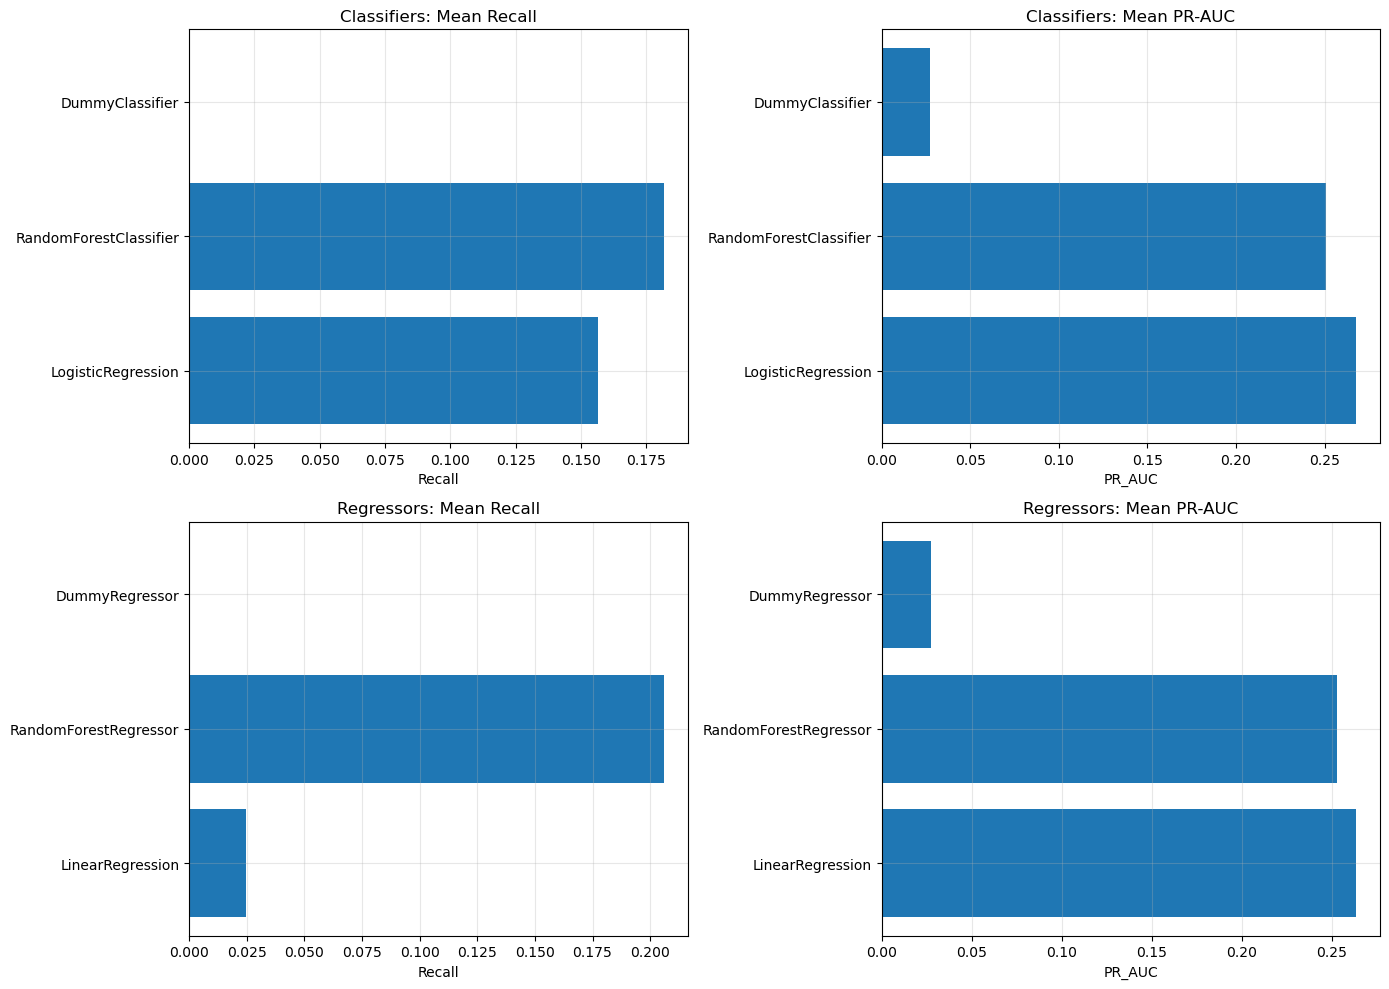

,Type,Model,Recall,PR_AUC
1,Classifier,LogisticRegression,0.156489,0.267834
2,Classifier,RandomForestClassifier,0.181712,0.251027
0,Classifier,DummyClassifier,0.000000,0.027534
4,Regressor,LinearRegression,0.024751,0.263440
5,Regressor,RandomForestRegressor,0.205887,0.252546
3,Regressor,DummyRegressor,0.000000,0.027534


In [13]:
# Compare mean Recall and PR_AUC, split by model family
plot_df = (
    cv_results
    .groupby(["Type", "Model"], as_index=False)[["Recall", "PR_AUC"]]
    .mean()
)

clf_df = plot_df[plot_df["Type"] == "Classifier"].sort_values("PR_AUC", ascending=False)
reg_df = plot_df[plot_df["Type"] == "Regressor"].sort_values("PR_AUC", ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].barh(clf_df["Model"], clf_df["Recall"])
axes[0, 0].set_title("Classifiers: Mean Recall")
axes[0, 0].set_xlabel("Recall")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].barh(clf_df["Model"], clf_df["PR_AUC"])
axes[0, 1].set_title("Classifiers: Mean PR-AUC")
axes[0, 1].set_xlabel("PR_AUC")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].barh(reg_df["Model"], reg_df["Recall"])
axes[1, 0].set_title("Regressors: Mean Recall")
axes[1, 0].set_xlabel("Recall")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].barh(reg_df["Model"], reg_df["PR_AUC"])
axes[1, 1].set_title("Regressors: Mean PR-AUC")
axes[1, 1].set_xlabel("PR_AUC")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

display(plot_df.sort_values(["Type", "PR_AUC"], ascending=[True, False]))

## Lead-Time Evaluation

The above metrics evaluate same-timestep predictions: features at hour $t$ predicting a storm at hour $t$. For an early warning system, we need to assess prediction lead time. In other words, how well do features at hour $t$ predict storms at $t + k$ hours (1h, 3h, 6h, 12h ahead).

Below we evaluate recall across multiple lead times to understand the useful prediction horizon and the tradeoff between warning distance and detection accuracy.

In [10]:
# Evaluate models across multiple lead times (1h, 3h, 6h, 12h)

lead_times = [1, 3, 6, 12]
lead_results = []

# Use a subset of models for speed (LogisticRegression and RandomForestClassifier)
all_models = [
    ("DummyClassifier", classification_models["DummyClassifier"], "Classifier"),
    ("LogisticRegression", classification_models["LogisticRegression"], "Classifier"),
    ("RandomForestClassifier", classification_models["RandomForestClassifier"], "Classifier"),
    ("DummyRegressor", regression_models["DummyRegressor"], "Regressor"),
    ("LinearRegression", regression_models["LinearRegression"], "Regressor"),
    ("RandomForestRegressor", regression_models["RandomForestRegressor"], "Regressor"),
]

for lead_hour in lead_times:
    # Create lagged target: shift storm indicator forward by lead_hour hours
    y_lagged = y.shift(-lead_hour)
    
    # Drop NaN values introduced by shifting
    valid_idx = y_lagged.notna()
    X_valid = X[valid_idx]
    y_valid = y_lagged[valid_idx]
    
    # Time series CV
    tscv_lead = TimeSeriesSplit(n_splits=5)
    
    for model_name, model, model_type in all_models:
        fold_recalls = []
        fold_precisions = []
        fold_f1s = []
        
        for fold, (train_idx, val_idx) in enumerate(tscv_lead.split(X_valid)):
            X_tr, X_val = X_valid.iloc[train_idx], X_valid.iloc[val_idx]
            y_tr, y_val = y_valid.iloc[train_idx], y_valid.iloc[val_idx]
            
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_val)
            
            # Convert regressor outputs to binary for classification metrics
            if model_type == "Regressor":
                y_pred = (y_pred >= 0.5).astype(int)
            
            fold_recalls.append(recall_score(y_val, y_pred, zero_division=0))
            fold_precisions.append(precision_score(y_val, y_pred, zero_division=0))
            fold_f1s.append(f1_score(y_val, y_pred, zero_division=0))
        
        lead_results.append({
            "Lead_Hours": lead_hour,
            "Model": model_name,
            "Mean_Recall": np.mean(fold_recalls),
            "Std_Recall": np.std(fold_recalls),
            "Mean_Precision": np.mean(fold_precisions),
            "Std_Precision": np.std(fold_precisions),
            "Mean_F1": np.mean(fold_f1s),
            "Std_F1": np.std(fold_f1s),
        })

lead_time_df = pd.DataFrame(lead_results)
display(lead_time_df)

,Lead_Hours,Model,Mean_Recall,Std_Recall,Mean_Precision,Std_Precision,Mean_F1,Std_F1
0,1,DummyClassifier,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,LogisticRegression,0.303148,0.184211,0.586643,0.309538,0.392977,0.222876
2,1,RandomForestClassifier,0.241164,0.133530,0.455938,0.239060,0.312669,0.166624
3,1,DummyRegressor,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,1,LinearRegression,0.043443,0.029914,0.700000,0.400000,0.079285,0.051584
5,1,RandomForestRegressor,0.326686,0.123599,0.461653,0.213304,0.374046,0.156060
6,3,DummyClassifier,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,3,LogisticRegression,0.186464,0.107920,0.442464,0.237957,0.260418,0.145932
8,3,RandomForestClassifier,0.123800,0.078205,0.427029,0.254509,0.186458,0.109299
9,3,DummyRegressor,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


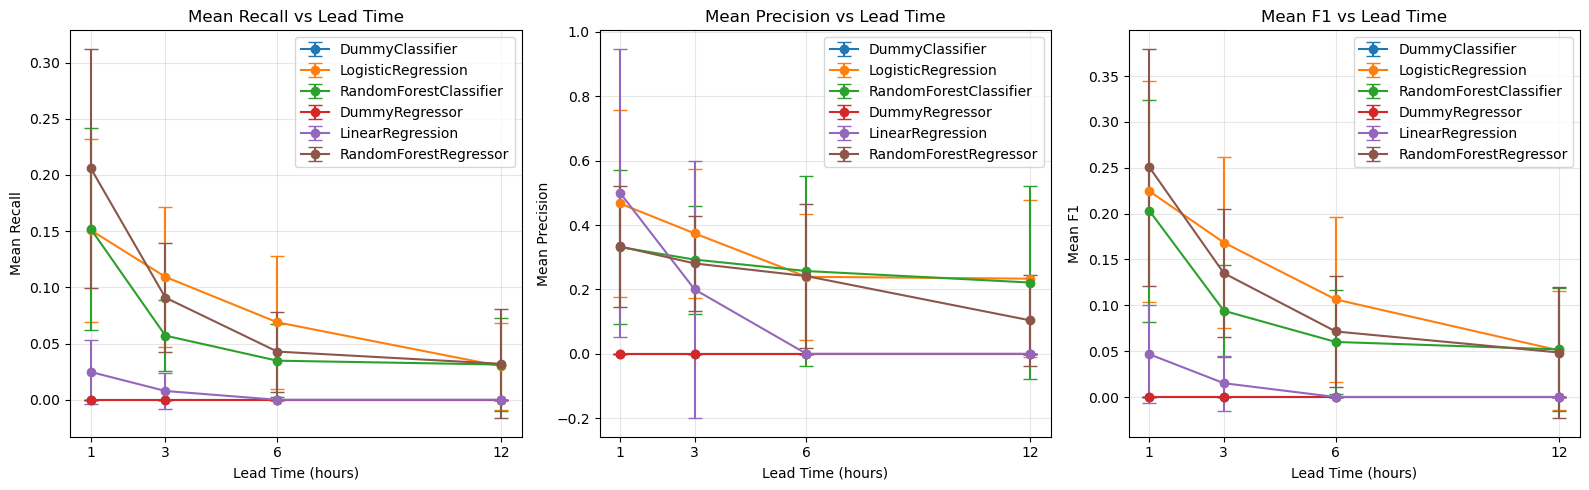


Top 3 configurations by recall (with precision and F1):


,Lead_Hours,Model,Mean_Recall,Mean_Precision,Mean_F1
5,1,RandomForestRegressor,0.205977,0.333431,0.250711
2,1,RandomForestClassifier,0.151982,0.331559,0.203327
1,1,LogisticRegression,0.150933,0.466861,0.224552


In [26]:
# Plot recall, precision, and F1 degradation across lead times
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ["Mean_Recall", "Mean_Precision", "Mean_F1"]):
    for model_name, model, model_type in all_models:
        model_data = lead_time_df[lead_time_df["Model"] == model_name]
        ax.errorbar(
            model_data["Lead_Hours"],
            model_data[metric],
            yerr=model_data[f"Std_{metric.split('_')[1]}"],
            marker='o',
            label=model_name,
            capsize=5
        )
    
    ax.set_xlabel("Lead Time (hours)")
    ax.set_ylabel(metric.replace('_', ' '))
    ax.set_title(f"{metric.replace('_', ' ')} vs Lead Time")
    ax.set_xticks(lead_times)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# Summary: which model and lead time maximize recall within acceptable precision?
print("\nTop 3 configurations by recall (with precision and F1):")
top_recall = lead_time_df.nlargest(3, "Mean_Recall")[["Lead_Hours", "Model", "Mean_Recall", "Mean_Precision", "Mean_F1"]]
display(top_recall)